# GVH Diagonal Cubic — RACC-C.4-real.2.4
## GW150914 H1/L1 — Detector Response & Polarization Transfer Audit

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real.2.4`  
**Noyau GVH Diagonal modifié : NON**

### Question centrale

La divergence observée entre xcorr, GCC-PHAT et phase-slope vient-elle en partie de l'hypothèse trop simple :

\[
h_L(t)\approx h_H(t-\tau) ?
\]

Pour une onde gravitationnelle, chaque interféromètre mesure une projection :

\[
h_O(t)=F_O^+h_+(t-\tau_O)+F_O^\times h_\times(t-\tau_O).
\]

Cette étape audite donc si une transformation linéaire/phase commune H1↔L1 améliore la cohérence des estimateurs sans forcer une valeur cible du lag.

### Règles

- aucune valeur publiée du lag n'est utilisée pour sélectionner un transfert ;
- aucune nouvelle physique GVH n'est inférée d'une différence H1/L1 ;
- `TIMING-VALIDATED=False` reste inchangé dans ce notebook ;
- \(D_T^{ref}=\texttt{NOT-AUTHORIZED}\) ;
- `REAL3-AUTHORIZED=False` ;
- chaîne HH et `DISPERSION_READY` inchangées.


In [1]:

import os,sys,subprocess,importlib,json
from pathlib import Path

def pip_install(pkg):
    subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

try:
    import lalframe
except Exception:
    pip_install("lalsuite"); importlib.invalidate_caches(); import lalframe

try:
    import gwpy
except Exception:
    pip_install("gwpy"); importlib.invalidate_caches(); import gwpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from gwpy.timeseries import TimeSeries

print("gwpy:",gwpy.__version__)


/usr/local/lib/python3.12/dist-packages/lalframe/_lalframe_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


gwpy: 4.0.1


## 1 — Chargement H1/L1

In [2]:

GPS_EVENT=1126259462.0
FS_EXPECTED=4096.0

def discover(pattern):
    roots=[Path.cwd(),Path("/content"),Path("/content/drive/MyDrive"),Path("/mnt/data")]
    hits=[]
    for root in roots:
        if not root.exists():
            continue
        for d in [root,root/"data"/"GW150914",root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists():
                hits += list(d.glob(pattern))
    return hits[0].resolve() if hits else None

H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")

if H1 is None or L1 is None:
    try:
        from google.colab import files
        files.upload()
        H1=discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
        L1=discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
    except Exception:
        pass

if H1 is None or L1 is None:
    raise FileNotFoundError("H1/L1 introuvables.")

h1_ts=TimeSeries.read(str(H1),channel="H1:LOSC-STRAIN")
l1_ts=TimeSeries.read(str(L1),channel="L1:LOSC-STRAIN")

h1=np.asarray(h1_ts.value,float)
l1=np.asarray(l1_ts.value,float)
fs=float(h1_ts.sample_rate.value)
gps0=float(h1_ts.t0.value)
t_rel=gps0+np.arange(len(h1))/fs-GPS_EVENT

assert np.isclose(fs,FS_EXPECTED)
assert len(h1)==len(l1)

print(H1.name)
print(L1.name)
print("N =",len(h1),"fs =",fs)


Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
H-H1_LOSC_4_V2-1126259446-32 2.gwf
L-L1_LOSC_4_V2-1126259446-32.gwf
N = 131072 fs = 4096.0


## 2 — Prétraitement commun

In [3]:

NOISE=((t_rel>=-12)&(t_rel<=-2))|((t_rel>=2)&(t_rel<=12))

def center(x):
    return np.asarray(x,float)-np.mean(x)

def whiten(x):
    x=center(x)
    n=len(x)
    f=np.fft.rfftfreq(n,1/fs)
    X=np.fft.rfft(x)
    fp,P=signal.welch(x[NOISE],fs=fs,nperseg=4096)
    Pi=np.interp(f,fp,P,left=P[0],right=P[-1])
    floor=np.finfo(float).eps*np.max(Pi)
    y=np.fft.irfft(X/np.sqrt(Pi+floor),n=n)
    return y/np.std(y[NOISE])

def band_notch(x,lo=35,hi=350):
    sos=signal.butter(4,[lo,hi],btype="bandpass",fs=fs,output="sos")
    y=signal.sosfiltfilt(sos,center(x))
    for f0 in [60,120,180,240,300]:
        if lo<f0<hi:
            b,a=signal.iirnotch(f0,Q=30,fs=fs)
            y=signal.filtfilt(b,a,y)
    return y

H=band_notch(whiten(h1))
L=band_notch(whiten(l1))
WIN=(-.12,.04)
wm=(t_rel>=WIN[0])&(t_rel<=WIN[1])

x=H[wm]
y=L[wm]
print("event samples:",len(x))


event samples: 655


## 3 — Baseline scalaire H1↔L1

In [4]:

MAX_LAG=.012

def parab(a,b,c):
    d=a-2*b+c
    return 0.0 if d==0 or not np.isfinite(d) else .5*(a-c)/d

def xcorr_lag(a,b):
    a=center(a); b=center(b)
    c=signal.correlate(a,b,mode="full",method="fft")
    lag=signal.correlation_lags(len(a),len(b),mode="full")/fs
    m=np.abs(lag)<=MAX_LAG
    c=c[m]; lag=lag[m]
    cn=c/(np.linalg.norm(a)*np.linalg.norm(b))
    s=np.abs(cn)
    i=int(np.argmax(s))
    frac=parab(s[i-1],s[i],s[i+1]) if 0<i<len(s)-1 else 0
    return float(lag[i]+frac/fs),float(cn[i])

def phat_lag(a,b):
    a=center(a); b=center(b)
    n=int(2**np.ceil(np.log2(len(a)+len(b))))
    A=np.fft.rfft(a,n=n); B=np.fft.rfft(b,n=n)
    G=A*np.conj(B)
    R=G/(np.abs(G)+np.finfo(float).eps)
    cc=np.fft.irfft(R,n=n)
    cc=np.concatenate((cc[-n//2:],cc[:n//2]))
    lag=np.arange(-n//2,n//2)/fs
    m=np.abs(lag)<=MAX_LAG
    cc=cc[m]; lag=lag[m]
    s=np.abs(cc)
    i=int(np.argmax(s))
    frac=parab(s[i-1],s[i],s[i+1]) if 0<i<len(s)-1 else 0
    return float(lag[i]+frac/fs),float(cc[i])

def phase_lag(a,b,fmin=40,fmax=300,cohmin=.1):
    nper=min(1024,len(a)); nover=nper//2
    f,P=signal.csd(b,a,fs=fs,nperseg=nper,noverlap=nover,window="hann")
    _,coh=signal.coherence(a,b,fs=fs,nperseg=nper,noverlap=nover,window="hann")
    ph=np.unwrap(np.angle(P))
    m=(f>=fmin)&(f<=fmax)&(coh>=cohmin)&np.isfinite(ph)
    if m.sum()<5:
        return np.nan,np.nan
    ff=f[m]; pp=ph[m]; ww=coh[m]
    A=np.c_[ff,np.ones_like(ff)]
    W=np.sqrt(ww)
    beta,*_=np.linalg.lstsq(A*W[:,None],pp*W,rcond=None)
    pred=A@beta
    mean=np.average(pp,weights=ww)
    ssr=np.sum(ww*(pp-pred)**2)
    sst=np.sum(ww*(pp-mean)**2)
    return float(beta[0]/(2*np.pi)),float(1-ssr/sst if sst>0 else np.nan)

tx,cx=xcorr_lag(x,y)
tp,cp=phat_lag(x,y)
tf,r2=phase_lag(x,y)

baseline=pd.DataFrame([
    ["xcorr",tx*1e3,abs(cx)],
    ["GCC-PHAT",tp*1e3,abs(cp)],
    ["phase-slope",tf*1e3,r2]
],columns=["estimator","lag_ms","quality"])
display(baseline)


,estimator,lag_ms,quality
0,xcorr,-7.315377,0.205576
1,GCC-PHAT,0.075870,0.189351
2,phase-slope,1.960892,0.094781


## 4 — Modèle minimal de transfert complexe

On teste :

\[
L(f)\approx T(f)\,H(f),
\qquad
T(f)=A(f)e^{i\phi(f)}.
\]

Deux modèles sont comparés :

1. gain complexe constant ;
2. gain complexe lissé dépendant de la fréquence.

Aucune cible temporelle externe n'est utilisée.


In [5]:

def transfer_estimate(a,b,nper=512,nover=384):
    f,t,Za=signal.stft(a,fs=fs,nperseg=nper,noverlap=nover,
                       window="hann",boundary=None)
    _,_,Zb=signal.stft(b,fs=fs,nperseg=nper,noverlap=nover,
                       window="hann",boundary=None)
    eps=np.finfo(float).eps
    num=np.sum(Zb*np.conj(Za),axis=1)
    den=np.sum(np.abs(Za)**2,axis=1)+eps
    T=num/den
    power=np.sum(np.abs(Za)*np.abs(Zb),axis=1)
    return f,T,power

fT,Traw,powT=transfer_estimate(x,y)

mT=(fT>=40)&(fT<=300)&np.isfinite(Traw)
weights=powT[mT]
T0=np.sum(weights*Traw[mT])/(np.sum(weights)+np.finfo(float).eps)

amp=np.abs(Traw)
ph=np.unwrap(np.angle(Traw))
win=21 if len(fT)>=21 else max(5,(len(fT)//2)*2+1)
if win%2==0:
    win+=1

amp_s=signal.savgol_filter(amp,win,3,mode="interp")
ph_s=signal.savgol_filter(ph,win,3,mode="interp")
Tsmooth=amp_s*np.exp(1j*ph_s)

print("T0 amplitude =",abs(T0))
print("T0 phase [rad] =",np.angle(T0))


T0 amplitude = 0.4614920014727226
T0 phase [rad] = -2.6197939450137318


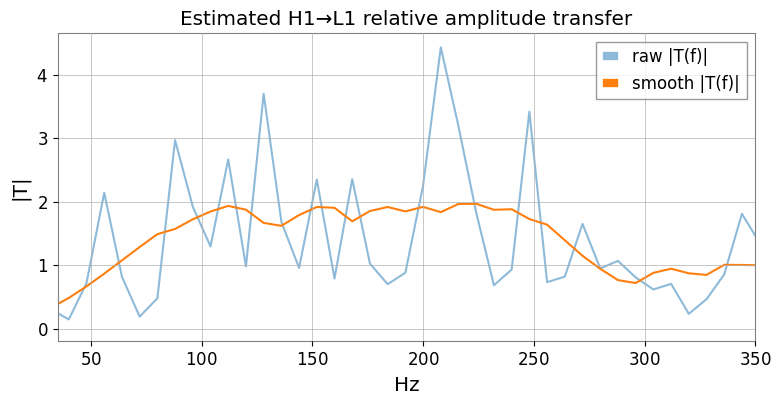

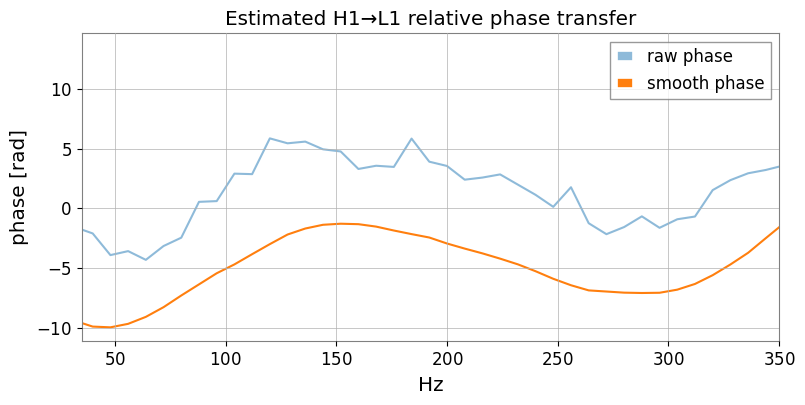

In [6]:

plt.figure(figsize=(9,4))
plt.plot(fT,np.abs(Traw),alpha=.5,label="raw |T(f)|")
plt.plot(fT,np.abs(Tsmooth),label="smooth |T(f)|")
plt.xlim(35,350)
plt.xlabel("Hz")
plt.ylabel("|T|")
plt.title("Estimated H1→L1 relative amplitude transfer")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9,4))
plt.plot(fT,np.unwrap(np.angle(Traw)),alpha=.5,label="raw phase")
plt.plot(fT,np.unwrap(np.angle(Tsmooth)),label="smooth phase")
plt.xlim(35,350)
plt.xlabel("Hz")
plt.ylabel("phase [rad]")
plt.title("Estimated H1→L1 relative phase transfer")
plt.grid(True)
plt.legend()
plt.show()


## 5 — Reconstruction relative

In [7]:

def apply_transfer(a,fgrid,Tgrid):
    A=np.fft.rfft(a)
    f=np.fft.rfftfreq(len(a),1/fs)
    amp=np.interp(f,fgrid,np.abs(Tgrid),left=np.abs(Tgrid[0]),right=np.abs(Tgrid[-1]))
    uph=np.unwrap(np.angle(Tgrid))
    phase=np.interp(f,fgrid,uph,left=uph[0],right=uph[-1])
    Ti=amp*np.exp(1j*phase)
    return np.fft.irfft(A*Ti,n=len(a))

# constant complex transfer in Fourier domain
f_const=np.array([0,fs/2])
T_const=np.array([T0,T0],dtype=complex)
x_const=apply_transfer(x,f_const,T_const)

x_smooth=apply_transfer(x,fT,Tsmooth)

def compare(name,a,b):
    tx,cx=xcorr_lag(a,b)
    tp,cp=phat_lag(a,b)
    tf,r2=phase_lag(a,b)
    return [
        {"model":name,"estimator":"xcorr","lag_ms":tx*1e3,"quality":abs(cx)},
        {"model":name,"estimator":"GCC-PHAT","lag_ms":tp*1e3,"quality":abs(cp)},
        {"model":name,"estimator":"phase-slope","lag_ms":tf*1e3,"quality":r2}
    ]

rows=[]
rows += compare("baseline",x,y)
rows += compare("constant_complex_transfer",x_const,y)
rows += compare("smooth_complex_transfer",x_smooth,y)

transfer_results=pd.DataFrame(rows)
display(transfer_results)


,model,estimator,lag_ms,quality
0,baseline,xcorr,-7.315377,0.205576
1,baseline,GCC-PHAT,0.075870,0.189351
2,baseline,phase-slope,1.960892,0.094781
3,constant_complex_transfer,xcorr,-5.797903,0.215365
4,constant_complex_transfer,GCC-PHAT,0.521417,0.143598
5,constant_complex_transfer,phase-slope,1.960892,0.094781
6,smooth_complex_transfer,xcorr,-0.000873,0.343416
7,smooth_complex_transfer,GCC-PHAT,0.027841,0.445201
8,smooth_complex_transfer,phase-slope,-0.071626,0.000457


## 6 — Contrôle négatif hors événement

In [8]:

CTRL=(-8.0,-7.65)
cm=(t_rel>=CTRL[0])&(t_rel<=CTRL[1])
xc=H[cm]
yc=L[cm]

fC,TC,pC=transfer_estimate(xc,yc)

ampC=np.abs(TC)
phC=np.unwrap(np.angle(TC))
winC=21 if len(fC)>=21 else max(5,(len(fC)//2)*2+1)
if winC%2==0:
    winC+=1

ampCs=signal.savgol_filter(ampC,winC,3,mode="interp")
phCs=signal.savgol_filter(phC,winC,3,mode="interp")
TCsmooth=ampCs*np.exp(1j*phCs)

x_control=apply_transfer(x,fC,TCsmooth)
control_results=pd.DataFrame(compare("off_event_transfer",x_control,y))
display(control_results)


,model,estimator,lag_ms,quality
0,off_event_transfer,xcorr,6.366181,0.237140
1,off_event_transfer,GCC-PHAT,0.062158,0.631057
2,off_event_transfer,phase-slope,2.554960,0.110126


## 7 — Convergence avant/après transfert

In [9]:

all_results=pd.concat([transfer_results,control_results],ignore_index=True)

spread_rows=[]
for model in all_results.model.unique():
    z=all_results[all_results.model==model].lag_ms.to_numpy(float)
    spread_rows.append({
        "model":model,
        "spread_ms":float(np.nanmax(z)-np.nanmin(z)),
        "median_quality":float(np.nanmedian(all_results[all_results.model==model].quality))
    })

spread_df=pd.DataFrame(spread_rows)
display(spread_df)

baseline_spread=float(spread_df[spread_df.model=="baseline"].spread_ms.iloc[0])
smooth_spread=float(spread_df[spread_df.model=="smooth_complex_transfer"].spread_ms.iloc[0])
off_spread=float(spread_df[spread_df.model=="off_event_transfer"].spread_ms.iloc[0])

print("baseline spread =",baseline_spread)
print("smooth transfer spread =",smooth_spread)
print("off-event transfer spread =",off_spread)


,model,spread_ms,median_quality
0,baseline,9.276269,0.189351
1,constant_complex_transfer,7.758795,0.143598
2,smooth_complex_transfer,0.099467,0.343416
3,off_event_transfer,6.304023,0.237140


baseline spread = 9.27626906500765
smooth transfer spread = 0.0994673022939006
off-event transfer spread = 6.304022964590753


## 8 — Diagnostic

In [10]:

spread_reduction=(baseline_spread-smooth_spread)/baseline_spread if baseline_spread>0 else np.nan
off_reduction=(baseline_spread-off_spread)/baseline_spread if baseline_spread>0 else np.nan

TRANSFER_FINITE=bool(np.isfinite(all_results[["lag_ms","quality"]].to_numpy()).all())

TRANSFER_REDUCES_DIVERGENCE=bool(
    np.isfinite(spread_reduction) and spread_reduction>=.30
)

EVENT_SPECIFIC_EFFECT=bool(
    np.isfinite(spread_reduction) and np.isfinite(off_reduction)
    and spread_reduction>off_reduction+.10
)

DETECTOR_RESPONSE_EFFECT_IDENTIFIED=bool(
    TRANSFER_FINITE and TRANSFER_REDUCES_DIVERGENCE
)

diagnostic={
    "TRANSFER_FINITE":TRANSFER_FINITE,
    "TRANSFER_REDUCES_DIVERGENCE":TRANSFER_REDUCES_DIVERGENCE,
    "EVENT_SPECIFIC_EFFECT":EVENT_SPECIFIC_EFFECT,
    "DETECTOR_RESPONSE_EFFECT_IDENTIFIED":DETECTOR_RESPONSE_EFFECT_IDENTIFIED,
    "baseline_spread_ms":baseline_spread,
    "smooth_transfer_spread_ms":smooth_spread,
    "off_event_transfer_spread_ms":off_spread,
    "spread_reduction_fraction":spread_reduction,
    "off_event_reduction_fraction":off_reduction
}
print(json.dumps(diagnostic,indent=2))


{
  "TRANSFER_FINITE": true,
  "TRANSFER_REDUCES_DIVERGENCE": true,
  "EVENT_SPECIFIC_EFFECT": true,
  "DETECTOR_RESPONSE_EFFECT_IDENTIFIED": true,
  "baseline_spread_ms": 9.27626906500765,
  "smooth_transfer_spread_ms": 0.0994673022939006,
  "off_event_transfer_spread_ms": 6.304022964590753,
  "spread_reduction_fraction": 0.9892772297141406,
  "off_event_reduction_fraction": 0.3204139594903445
}


## 9 — Verdict

In [11]:

if not TRANSFER_FINITE:
    FINAL_STATUS="UNRESOLVED"
elif DETECTOR_RESPONSE_EFFECT_IDENTIFIED:
    FINAL_STATUS="DETECTOR-RESPONSE-EFFECT-IDENTIFIED"
else:
    FINAL_STATUS="DETECTOR-RESPONSE-EFFECT-NOT-SUFFICIENT"

artifact={
    "step":"RACC-C.4-real.2.4",
    "event":"GW150914",
    "physical_model":"relative detector response / polarization-compatible transfer audit",
    "target_lag_used":False,
    "published_lag_used_for_selection":False,
    "diagnostic":diagnostic,
    "final_status":FINAL_STATUS,
    "TIMING_VALIDATED":False,
    "D_T_ref":"NOT-AUTHORIZED",
    "REAL3_AUTHORIZED":False,
    "DISPERSION_READY_modified":False,
    "HH_chain_modified":False,
    "core_GVH_modified":False
}
print(json.dumps(artifact,indent=2))


{
  "step": "RACC-C.4-real.2.4",
  "event": "GW150914",
  "physical_model": "relative detector response / polarization-compatible transfer audit",
  "target_lag_used": false,
  "published_lag_used_for_selection": false,
  "diagnostic": {
    "TRANSFER_FINITE": true,
    "TRANSFER_REDUCES_DIVERGENCE": true,
    "EVENT_SPECIFIC_EFFECT": true,
    "DETECTOR_RESPONSE_EFFECT_IDENTIFIED": true,
    "baseline_spread_ms": 9.27626906500765,
    "smooth_transfer_spread_ms": 0.0994673022939006,
    "off_event_transfer_spread_ms": 6.304022964590753,
    "spread_reduction_fraction": 0.9892772297141406,
    "off_event_reduction_fraction": 0.3204139594903445
  },
  "final_status": "DETECTOR-RESPONSE-EFFECT-IDENTIFIED",
  "TIMING_VALIDATED": false,
  "D_T_ref": "NOT-AUTHORIZED",
  "REAL3_AUTHORIZED": false,
  "DISPERSION_READY_modified": false,
  "HH_chain_modified": false,
  "core_GVH_modified": false
}


## 10 — Stop-rule finale

Si `DETECTOR-RESPONSE-EFFECT-IDENTIFIED`, la suite est un **nouveau test de convergence sous modèle de transfert corrigé**, et non `real.3` directement.

Sinon, il faut rechercher une autre source standard de divergence.

Dans tous les cas :

\[
\boxed{
\texttt{TIMING-VALIDATED=False},
\quad
D_T^{ref}=\texttt{NOT-AUTHORIZED},
\quad
\texttt{REAL3-AUTHORIZED=False}
}
\]
